In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
# Membaca file CSV
df = pd.read_csv('Cereals.csv')

# Menampilkan 5 baris pertama dari data
df.head()


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,25,3,1.0,0.75,34.384843


In [ ]:
# Melihat informasi umum tentang jumlah baris, kolom, tipe data, dan nilai yang kosong (Missing Values)
df.info()

# Melihat statistik deskriptif dari data angka
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     76 non-null     float64
 9   sugars    76 non-null     float64
 10  potass    75 non-null     float64
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(7), int64(6), object(3)
memory usage: 9.8+ KB


,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,76.000000,76.000000,75.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.802632,7.026316,98.666667,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,3.907326,4.378656,70.410636,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,42.500000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


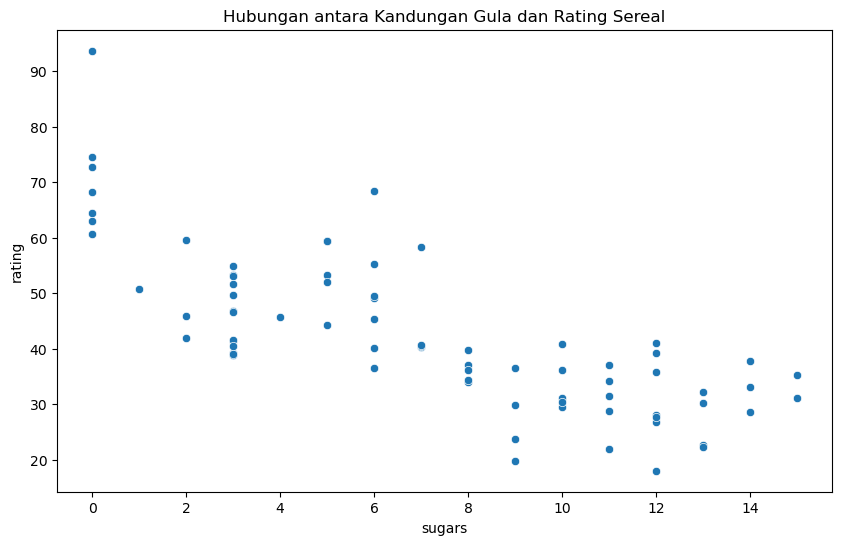

In [10]:
plt.figure(figsize=(10, 6))
# Membuat plot korelasi antara kandungan Gula (sugars) dan Rating
sns.scatterplot(data=df, x='sugars', y='rating')
plt.title('Hubungan antara Kandungan Gula dan Rating Sereal')
plt.show()


In [11]:
# Hapus baris yang memiliki nilai kosong (NaN) agar aman
df_clean = df.dropna()

# Kita akan memilih kolom angka saja (fitur-fitur nutrisi) untuk memprediksi kolom target ('rating')
# Kolom seperti name, mfr, dan type bertipe teks/kategori jadi kita sisihkan dulu untuk model pemula ini.
fitur_nutrisi = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'weight', 'cups']

X = df_clean[fitur_nutrisi] # Variabel Bebas (Fitur)
y = df_clean['rating']      # Variabel Terikat (Target yang mau diprediksi)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {X_train.shape[0]} baris")
print(f"Jumlah data uji: {X_test.shape[0]} baris")


Jumlah data latih: 59 baris
Jumlah data uji: 15 baris


In [13]:
# Membuat objek model
model = LinearRegression()

# Melatih model menggunakan data latih
model.fit(X_train, y_train)

print("Model berhasil dilatih!")


Model berhasil dilatih!


In [16]:
# Membuat prediksi menggunakan data uji
y_pred = model.predict(X_test)

# Menghitung eror (R-squared). Jika nilainya mendekati 1.0, berarti prediksinya sangat akurat!
r2 = r2_score(y_test, y_pred)
print(f"Akurasi Model (R-squared): {r2:.4f}")

# Coba kita bandingkan antara hasil Prediksi AI dengan hasil aslinya (Nilai Aktual)
perbandingan = pd.DataFrame({'Aktual (Asli)': y_test, 'Prediksi AI': y_pred})
print(perbandingan.head())


Akurasi Model (R-squared): 1.0000
    Aktual (Asli)  Prediksi AI
5       29.509541    29.509541
66      31.230054    31.230055
19      40.448772    40.448772
0       68.402973    68.402973
30      35.252444    35.252444
